In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
res = pd.read_csv("results.csv")
res

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
0,0,f9aca_00000,0,0.805926,least_confidence,1,93.111648
1,1,f9aca_00000,1,0.884815,least_confidence,1,93.111648
2,2,f9aca_00000,2,0.814242,least_confidence,1,93.111648
3,3,f9aca_00000,3,0.857407,least_confidence,1,93.111648
4,4,f9aca_00000,4,0.868077,least_confidence,1,93.111648
...,...,...,...,...,...,...,...
2645,2645,f9aca_00024,101,0.927879,random,5,96.385625
2646,2646,f9aca_00024,102,0.940657,random,5,96.385625
2647,2647,f9aca_00024,103,0.927879,random,5,96.385625
2648,2648,f9aca_00024,104,0.927879,random,5,96.385625


In [3]:
res[res.strategy=="random"]

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
2120,2120,f9aca_00020,0,0.808405,random,1,89.464825
2121,2121,f9aca_00020,1,0.806936,random,1,89.464825
2122,2122,f9aca_00020,2,0.852692,random,1,89.464825
2123,2123,f9aca_00020,3,0.795584,random,1,89.464825
2124,2124,f9aca_00020,4,0.814815,random,1,89.464825
...,...,...,...,...,...,...,...
2645,2645,f9aca_00024,101,0.927879,random,5,96.385625
2646,2646,f9aca_00024,102,0.940657,random,5,96.385625
2647,2647,f9aca_00024,103,0.927879,random,5,96.385625
2648,2648,f9aca_00024,104,0.927879,random,5,96.385625


In [4]:
aucs = res.drop_duplicates(subset=["strategy","seed"])
agg = aucs.groupby("strategy")["score"]
mean_aucs, std_aucs = agg.mean(), agg.std()
aucs = pd.concat((mean_aucs, std_aucs), axis=1)
aucs.columns = ["avg", "stdv"]
aucs["score"] = aucs.apply(lambda row: f"{row.avg:.2f} ± {row.stdv:.2f}"  ,axis=1)
label_to_auc = dict(zip(aucs.index, aucs["score"]))

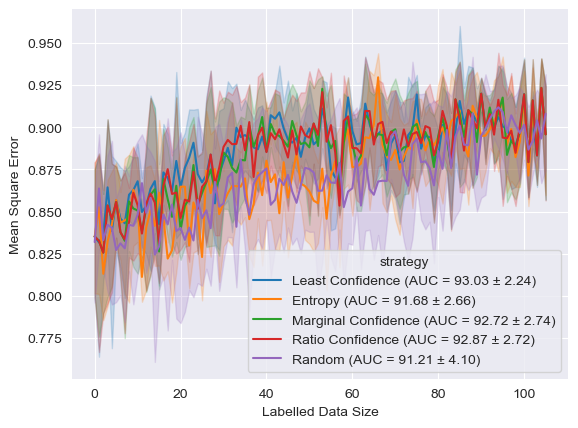

In [5]:
sns.set_style("darkgrid")

sns.lineplot(data=res, x="iteration", y="test_metric", hue="strategy")
plt.ylabel("Mean Square Error")
plt.xlabel("Labelled Data Size")
# _ = plt.xticks(np.arange(0,26), np.arange(0,26)*10 + 20, rotation=45)

ax = plt.gca()
legend = ax.get_legend()
for text in legend.get_texts():
    label = text.get_text()
    new_label = f"{label.replace('_', ' ').title()} (AUC = {label_to_auc[label]})"
    text.set_text(new_label)
    

for spine in ax.spines.values():
    spine.set_visible(False)